In [1]:
import sys  # 导入所需模块
import warnings  # 导入所需模块

if not sys.warnoptions:  # 条件判断
    warnings.simplefilter('ignore')  # 设置警告过滤级别

In [2]:
import tensorflow as tf  # 导入所需模块
import numpy as np  # 导入所需模块
import matplotlib.pyplot as plt  # 导入所需模块
import seaborn as sns  # 导入所需模块
import pandas as pd  # 导入所需模块
from sklearn.preprocessing import MinMaxScaler  # 导入所需模块
from datetime import datetime  # 导入所需模块
from datetime import timedelta  # 导入所需模块
from tqdm import tqdm  # 导入所需模块
sns.set()  # 执行该语句
tf.compat.v1.random.set_random_seed(1234)  # 固定随机种子保证可复现

In [3]:
df = pd.read_csv('../dataset/GOOG-year.csv')  # 读取 CSV 数据文件
df.head()  # 查看数据前几行

,Date,Open,High,Low,Close,Adj Close,Volume
0,2016-11-02,778.200012,781.650024,763.450012,768.700012,768.700012,1872400
1,2016-11-03,767.250000,769.950012,759.030029,762.130005,762.130005,1943200
2,2016-11-04,750.659973,770.359985,750.560974,762.020020,762.020020,2134800
3,2016-11-07,774.500000,785.190002,772.549988,782.520020,782.520020,1585100
4,2016-11-08,783.400024,795.632996,780.190002,790.510010,790.510010,1350800


In [4]:
minmax = MinMaxScaler().fit(df.iloc[:, 4:5].astype('float32'))  # 创建归一化器, 在收盘价(第5列, 索引4)上拟合 min/max
df_log = minmax.transform(df.iloc[:, 4:5].astype('float32'))  # 用拟合好的 min/max 把收盘价缩放到 [0,1]
df_log = pd.DataFrame(df_log)  # 构造 DataFrame
df_log.head()  # 查看数据前几行

,0
0,0.112708
1,0.090008
2,0.089628
3,0.160459
4,0.188066


## Split train and test

I will cut the dataset to train and test datasets,

1. Train dataset derived from starting timestamp until last 30 days
2. Test dataset derived from last 30 days until end of the dataset

So we will let the model do forecasting based on last 30 days, and we will going to repeat the experiment for 10 times. You can increase it locally if you want, and tuning parameters will help you by a lot.

# LSTM 长短期记忆网络

> 门控循环网络 · 适合长程依赖的时序预测
## 算法原理：LSTM（长短期记忆网络）

### 核心思想
LSTM 通过引入**细胞状态 $C_t$**（一条贯穿时间的信息高速公路）和三个**门控**（遗忘门、输入门、输出门），精确控制信息的"遗忘、写入、读出"，从根本上缓解了 Vanilla RNN 的梯度消失问题，从而能够捕捉**长程依赖**。

### 数学公式
- 遗忘门：$f_t = \sigma(W_f[h_{t-1}, x_t] + b_f)$
- 输入门：$i_t = \sigma(W_i[h_{t-1}, x_t] + b_i)$
- 候选记忆：$\tilde{C}_t = \tanh(W_C[h_{t-1}, x_t] + b_C)$
- 细胞状态更新：$C_t = f_t\odot C_{t-1} + i_t\odot\tilde{C}_t$
- 输出门：$o_t = \sigma(W_o[h_{t-1}, x_t] + b_o)$
- 隐状态：$h_t = o_t\odot\tanh(C_t)$

其中 $\sigma$ 为 sigmoid，$\odot$ 为逐元素乘。遗忘门 $f_t$ 决定保留多少旧记忆，输入门 $i_t$ 决定写入多少新信息。

### 与经典算法对比
| 维度 | LSTM | Vanilla RNN | GRU | ARIMA |
|---|---|---|---|---|
| 长程依赖 | 优秀 | 差 | 良好 | 弱 |
| 参数量 | 多（4 套门） | 少 | 中（3 套门） | 少 |
| 训练速度 | 较慢 | 快 | 较快 | 快 |
| 适合序列长度 | 长（数百步） | 短 | 中长 | 短 |

### 优势
- 通过细胞状态与门控，**有效解决梯度消失**，是时序预测的事实标准之一。
- 在本项目中 LSTM 达到约 **95.7%** 的信号预测准确率，明显优于 Vanilla RNN（~91%）。
## 实验流程与评估

本 notebook 采用统一的端到端流程：

1. **数据加载**：读取 `../dataset/` 下的行情 CSV（默认 Google 年线数据）。
2. **归一化**：用 `MinMaxScaler` 将收盘价映射到 `[0, 1]`，消除量纲、加速收敛：
   $$x'=\frac{x-x_{\min}}{x_{\max}-x_{\min}}$$
3. **划分**：最后 `test_size`（默认 30 天）作测试集，其余作训练集。
4. **训练**：以 `timestamp` 为时间步长切窗，最小化均方误差 $\text{MSE}=\frac{1}{N}\sum(y-\hat y)^2$。
5. **递推预测**：训练后在序列末尾用模型自身输出滚动喂回，自回归地预测未来 `test_size` 天。
6. **后处理**：`minmax.inverse_transform` 反归一化还原真实价格，再用 `anchor(signal, 0.3)` 做指数加权平滑：
   $$s_t = w\cdot s_{t-1} + (1-w)\cdot x_t$$
7. **蒙特卡洛模拟**：重复 `simulation_size`（默认 10）次取平均，评估稳定性；准确率定义为
   $$\text{Acc}=100\times\left(1-\sqrt{\text{mean}\left(\left(\frac{y-\hat y}{y}\right)^2\right)}\right)$$

> 说明：模型使用 TensorFlow 1.x 图模式（`tf.placeholder` / `tf.nn.dynamic_rnn`），需在 TF 1.x 环境运行。

In [5]:
test_size = 30  # 设置测试集天数
simulation_size = 10  # 设置蒙特卡洛模拟重复次数

df_train = df_log.iloc[:-test_size]  # 按位置索引切片
df_test = df_log.iloc[-test_size:]  # 按位置索引切片
df.shape, df_train.shape, df_test.shape  # 执行该语句

((252, 7), (222, 1), (30, 1))

In [6]:
class Model:  # 定义类 Model
    def __init__(  # 定义函数 __init__
        self,  # 类方法自身引用
        learning_rate,  # 设置学习率
        num_layers,  # 设置 RNN 堆叠层数
        size,  # 函数参数 size
        size_layer,  # 设置隐藏层神经元数量
        output_size,  # 函数参数 output_size
        forget_bias = 0.1,  # 设置遗忘门偏置
    ):  # 参数列表结束
        def lstm_cell(size_layer):  # 定义函数 lstm_cell
            return tf.nn.rnn_cell.LSTMCell(size_layer, state_is_tuple = False)  # 创建 LSTM 循环单元

        rnn_cells = tf.nn.rnn_cell.MultiRNNCell(  # 堆叠多层 RNN 单元
            [lstm_cell(size_layer) for _ in range(num_layers)],  # 执行该语句
            state_is_tuple = False,  # 函数参数 state_is_tuple
        )  # 参数列表结束
        self.X = tf.placeholder(tf.float32, (None, None, size))  # 定义 TensorFlow 输入占位符
        self.Y = tf.placeholder(tf.float32, (None, output_size))  # 定义 TensorFlow 输入占位符
        drop = tf.contrib.rnn.DropoutWrapper(  # 为 RNN 包装 Dropout
            rnn_cells, output_keep_prob = forget_bias  # 为变量 output_keep_prob 赋值
        )  # 参数列表结束
        self.hidden_layer = tf.placeholder(  # 定义 TensorFlow 输入占位符
            tf.float32, (None, num_layers * 2 * size_layer)  # 执行该语句
        )  # 参数列表结束
        self.outputs, self.last_state = tf.nn.dynamic_rnn(  # 运行动态 RNN 前向传播
            drop, self.X, initial_state = self.hidden_layer, dtype = tf.float32  # 为变量 initial_state 赋值
        )  # 参数列表结束
        self.logits = tf.layers.dense(self.outputs[-1], output_size)  # 定义全连接层
        self.cost = tf.reduce_mean(tf.square(self.Y - self.logits))  # 计算均值（常用于损失）
        self.optimizer = tf.train.AdamOptimizer(learning_rate).minimize(  # 创建 Adam 优化器
            self.cost  # 执行该语句
        )  # 参数列表结束

def calculate_accuracy(real, predict):  # 定义函数 calculate_accuracy
    real = np.array(real) + 1  # 创建 NumPy 数组
    predict = np.array(predict) + 1  # 创建 NumPy 数组
    percentage = 1 - np.sqrt(np.mean(np.square((real - predict) / real)))  # 计算均值
    return percentage * 100  # 返回结果

def anchor(signal, weight):  # 定义函数 anchor
    buffer = []  # 为变量 buffer 赋值
    last = signal[0]  # 为变量 last 赋值
    for i in signal:  # 循环遍历
        smoothed_val = last * weight + (1 - weight) * i  # 为变量 smoothed_val 赋值
        buffer.append(smoothed_val)  # 向列表追加元素
        last = smoothed_val  # 函数参数 last
    return buffer  # 返回结果

In [7]:
num_layers = 1  # 设置 RNN 堆叠层数
size_layer = 128  # 设置隐藏层神经元数量
timestamp = 5  # 设置时间窗口步长
epoch = 300  # 设置训练轮数
dropout_rate = 0.8  # 设置 Dropout 保留率
future_day = test_size  # 设置预测的未来天数
learning_rate = 0.01  # 设置学习率

In [8]:
def forecast():  # 定义函数 forecast
    tf.reset_default_graph()  # 重置默认计算图
    modelnn = Model(  # 模型实例
        learning_rate, num_layers, df_log.shape[1], size_layer, df_log.shape[1], dropout_rate  # 执行该语句
    )  # 参数列表结束
    sess = tf.InteractiveSession()  # 创建交互式会话
    sess.run(tf.global_variables_initializer())  # 初始化全部全局变量
    date_ori = pd.to_datetime(df.iloc[:, 0]).tolist()  # 转换为日期时间类型

    pbar = tqdm(range(epoch), desc = 'train loop')  # 创建进度条
    for i in pbar:  # 循环遍历
        init_value = np.zeros((1, num_layers * 2 * size_layer))  # 创建全零数组
        total_loss, total_acc = [], []  # 累计训练准确率
        for k in range(0, df_train.shape[0] - 1, timestamp):  # 循环遍历
            index = min(k + timestamp, df_train.shape[0] - 1)  # 为变量 index 赋值
            batch_x = np.expand_dims(  # 扩展数组维度
                df_train.iloc[k : index, :].values, axis = 0  # 按位置索引切片
            )  # 参数列表结束
            batch_y = df_train.iloc[k + 1 : index + 1, :].values  # 按位置索引切片
            logits, last_state, _, loss = sess.run(  # 为变量 loss 赋值
                [modelnn.logits, modelnn.last_state, modelnn.optimizer, modelnn.cost],  # 执行该语句
                feed_dict = {  # 函数参数 feed_dict
                    modelnn.X: batch_x,  # 执行该语句
                    modelnn.Y: batch_y,  # 执行该语句
                    modelnn.hidden_layer: init_value,  # 执行该语句
                },  # 执行该语句
            )  # 参数列表结束
            init_value = last_state  # RNN 隐藏状态初值
            total_loss.append(loss)  # 向列表追加元素
            total_acc.append(calculate_accuracy(batch_y[:, 0], logits[:, 0]))  # 向列表追加元素
        pbar.set_postfix(cost = np.mean(total_loss), acc = np.mean(total_acc))  # 计算均值
    
    future_day = test_size  # 设置预测的未来天数

    output_predict = np.zeros((df_train.shape[0] + future_day, df_train.shape[1]))  # 创建全零数组
    output_predict[0] = df_train.iloc[0]  # 按位置索引切片
    upper_b = (df_train.shape[0] // timestamp) * timestamp  # 为变量 upper_b 赋值
    init_value = np.zeros((1, num_layers * 2 * size_layer))  # 创建全零数组

    for k in range(0, (df_train.shape[0] // timestamp) * timestamp, timestamp):  # 循环遍历
        out_logits, last_state = sess.run(  # 为变量 last_state 赋值
            [modelnn.logits, modelnn.last_state],  # 执行该语句
            feed_dict = {  # 函数参数 feed_dict
                modelnn.X: np.expand_dims(  # 扩展数组维度
                    df_train.iloc[k : k + timestamp], axis = 0  # 按位置索引切片
                ),  # 执行该语句
                modelnn.hidden_layer: init_value,  # 执行该语句
            },  # 执行该语句
        )  # 参数列表结束
        init_value = last_state  # RNN 隐藏状态初值
        output_predict[k + 1 : k + timestamp + 1] = out_logits  # 为变量 1 赋值

    if upper_b != df_train.shape[0]:  # 条件判断
        out_logits, last_state = sess.run(  # 为变量 last_state 赋值
            [modelnn.logits, modelnn.last_state],  # 执行该语句
            feed_dict = {  # 函数参数 feed_dict
                modelnn.X: np.expand_dims(df_train.iloc[upper_b:], axis = 0),  # 扩展数组维度
                modelnn.hidden_layer: init_value,  # 执行该语句
            },  # 执行该语句
        )  # 参数列表结束
        output_predict[upper_b + 1 : df_train.shape[0] + 1] = out_logits  # 为变量 1 赋值
        future_day -= 1  # 设置预测的未来天数
        date_ori.append(date_ori[-1] + timedelta(days = 1))  # 向列表追加元素

    init_value = last_state  # RNN 隐藏状态初值
    
    for i in range(future_day):  # 循环遍历
        o = output_predict[-future_day - timestamp + i:-future_day + i]  # 为变量 o 赋值
        out_logits, last_state = sess.run(  # 为变量 last_state 赋值
            [modelnn.logits, modelnn.last_state],  # 执行该语句
            feed_dict = {  # 函数参数 feed_dict
                modelnn.X: np.expand_dims(o, axis = 0),  # 扩展数组维度
                modelnn.hidden_layer: init_value,  # 执行该语句
            },  # 执行该语句
        )  # 参数列表结束
        init_value = last_state  # RNN 隐藏状态初值
        output_predict[-future_day + i] = out_logits[-1]  # 为变量 i 赋值
        date_ori.append(date_ori[-1] + timedelta(days = 1))  # 向列表追加元素
    
    output_predict = minmax.inverse_transform(output_predict)  # 执行反归一化还原真实值
    deep_future = anchor(output_predict[:, 0], 0.3)  # 平滑后的未来预测
    
    return deep_future[-test_size:]  # 返回结果

In [9]:
results = []  # 各次模拟的预测结果列表
for i in range(simulation_size):  # 循环遍历
    print('simulation %d'%(i + 1))  # 打印输出
    results.append(forecast())  # 向列表追加元素

simulation 1
Instructions for updating:
This class is equivalent as tf.keras.layers.LSTMCell, and will be replaced by that in Tensorflow 2.0.
Instructions for updating:
This class is equivalent as tf.keras.layers.StackedRNNCells, and will be replaced by that in Tensorflow 2.0.
The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.

Instructions for updating:
Please use `keras.layers.RNN(cell)`, which is equivalent to this API
Instructions for updating:
Please use `layer.add_weight` method instead.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Use keras.layers.Dense instead.
Instructions

train loop: 100%|██████████| 300/300 [00:42<00:00,  7.07it/s, acc=97.3, cost=0.00182]


simulation 2


train loop: 100%|██████████| 300/300 [00:39<00:00,  7.53it/s, acc=97.4, cost=0.0018] 


simulation 3


...

train loop: 100%|██████████| 300/300 [00:39<00:00,  7.57it/s, acc=97.4, cost=0.00186]


simulation 9


train loop: 100%|██████████| 300/300 [00:39<00:00,  7.54it/s, acc=97.1, cost=0.00224]


simulation 10


train loop: 100%|██████████| 300/300 [00:38<00:00,  7.80it/s, acc=96.9, cost=0.00282]


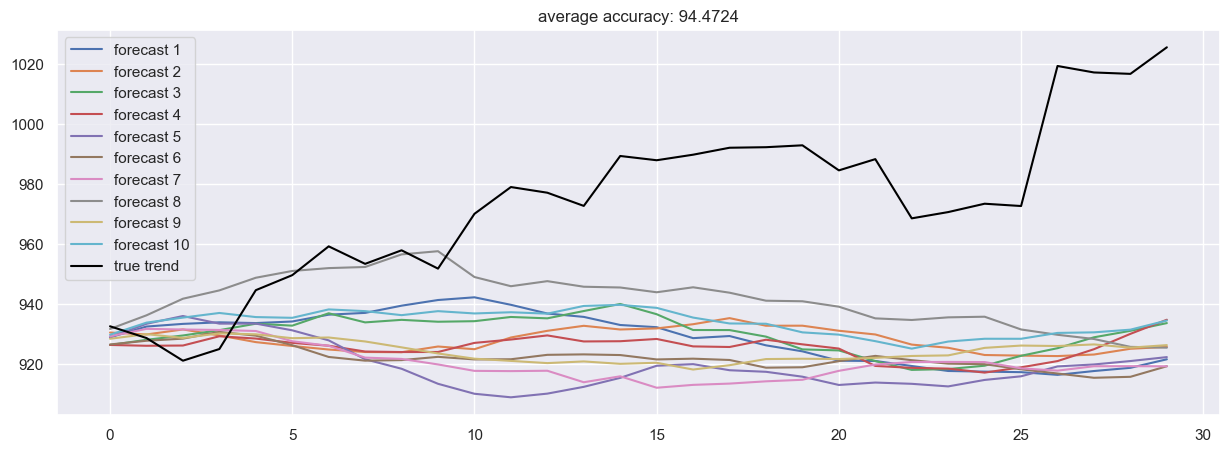

In [10]:
accuracies = [calculate_accuracy(df['Close'].iloc[-test_size:].values, r) for r in results]  # 按位置索引切片

plt.figure(figsize = (15, 5))  # 创建图形画布
for no, r in enumerate(results):  # 循环遍历
    plt.plot(r, label = 'forecast %d'%(no + 1))  # 绘制折线
plt.plot(df['Close'].iloc[-test_size:].values, label = 'true trend', c = 'black')  # 绘制折线
plt.legend()  # 显示图例
plt.title('average accuracy: %.4f'%(np.mean(accuracies)))  # 设置图表标题
plt.show()  # 显示绘制的图像